# 2.3. Содержание ноутбука

## 2.3.1. Загрузка данных и первичный осмотр

## 1. импорт библиотек

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. загрузка датасета

In [123]:
df = pd.read_csv('S02-hw-dataset.csv', sep = ',')
#df

## 3. вывод

### первые строки

In [124]:
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


### информация о столбцах и типах 

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


### базовые описательные статистики

In [126]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


## 2.3.2. Пропуски, дубликаты и базовый контроль качества

### 1. Посчитать долю пропусков в каждом столбце

In [127]:
df.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

### 2. Проверить наличие полностью дублирующих строк

In [128]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool

### 3. Найти и вывести «подозрительные» случаи, исходя из смысла датасета

пустые ячейки

In [129]:
for col in df.columns:
    print("===column :",col,"===")
    for row in df.index:
        if pd.isna(df.loc[row,col]):
            print("row", row, "is Nan")
    print()

===column : user_id ===

===column : age ===
row 4 is Nan
row 12 is Nan

===column : country ===

===column : purchases ===

===column : revenue ===



отрицательные ячейки

In [130]:
col = ['user_id','age','purchases','revenue']
for c in col:
    print("===column :",c,"===")
    for row in df.index:
        if df.loc[row,c] < 0:
            print("row", row, "is negative")
    print()

===column : user_id ===

===column : age ===

===column : purchases ===
row 5 is negative

===column : revenue ===



нереалистичный возраст

In [131]:
for row in df.index:
        if df.loc[row,'age'] > 100:
            print("age in row", row, "is unrealistic")

age in row 5 is unrealistic


покупки при нулевом доходе

In [132]:
for row in df.index:
        if df.loc[row,'revenue'] == 0 and df.loc[row,'purchases'] > 0:
            print("count of purchases in row", row, "is unrealistic")

count of purchases in row 10 is unrealistic


### 4. Кратко (1-2 абзаца) описать текстом, какие проблемы качества данных были обнаружены

Обнаружена одна полностью совпадающая строка. Имеются пустые ячейки в столбце age. Обнаружены отрицательные ячейки в разделе с покупками. обнаружен нереалистичный возраст. Обнаружен покупатель с нулевым доходом, который что-то купил.

### 5. Чистка данных

In [133]:
print("Было:",df.shape)
df = df.drop_duplicates() # удаление дубликатов
df = df.dropna() # удаление строк с пропусками
col = ['user_id','age','purchases','revenue']
for row in df.index: # удаление отрицательных значений
    for c in col:
        if df.loc[row,c] < 0:
            df = df.drop(index=row)
            break
for row in df.index: # удаление нереалистичного возраста
        if df.loc[row,'age'] > 100:
            df = df.drop(index=row)
for row in df.index: # удаление покупок при нулевом доходе
        if df.loc[row,'revenue'] <= 0 and df.loc[row,'purchases'] > 0:
            df = df.drop(index=row)
print("Стало:",df.shape)
df = df.reset_index(drop=True)
df

Было: (41, 5)
Стало: (36, 5)


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,7,46.0,RU,0,0
5,8,28.0,CN,2,456
6,9,39.0,US,4,980
7,10,24.0,RU,7,511
8,12,20.0,CN,7,1652
9,14,36.0,DE,9,2358


## 2.3.3. Базовый EDA: группировки, агрегаты и частоты

### 1. Посчитать частоты для одной или двух категориальных переменных

In [134]:
df['country'].value_counts()

country
RU    12
FR    11
US     6
DE     5
CN     2
Name: count, dtype: int64

### 2. Выполнить хотя бы одну осмысленную группировку с агрегатами через groupby

In [135]:
country_group = df.groupby('country')
country_group['age'].median()

country
CN    24.0
DE    35.0
FR    39.0
RU    28.5
US    40.5
Name: age, dtype: float64

In [136]:
country_group['purchases'].median()

country
CN    4.5
DE    6.0
FR    6.0
RU    5.5
US    4.0
Name: purchases, dtype: float64

In [137]:
country_group['revenue'].median()

country
CN    1054.0
DE    1104.0
FR     546.0
RU     652.0
US     636.5
Name: revenue, dtype: float64

### 3. При необходимости ввести дополнительные «коридоры» (bins) или группировки (например, возрастные группы, диапазоны значений и т.п.).

In [138]:
cuted = pd.cut(df['age'], bins = [0,30,60,100], labels = ['молодой','Средний возраст','Старый'], right = False)
df.groupby(cuted).size()

C:\Users\TUF A15\AppData\Local\Temp\ipykernel_11232\3499210914.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cuted).size()


age
молодой            13
Средний возраст    23
Старый              0
dtype: int64

### 4. описать текстом основные наблюдения

По национальной категории доминируют русские. По возрастной люди среднего возраста (30-60 лет).

По средним значениям. Максимальный средний возраст покупателей у французов, минимальный - у китайцев. Максимальное среднее количество покупок совершают одновременно немцы и французы, минимальное - американцы. Максимальная средняя зарплата у немцев, минимальная - у французов.

Неожиданные данные. Никто из категории старых (старше 60) не совершал покупок

# 2.4. Визуализация данных в Matplotlib

### 1. Гистограмма

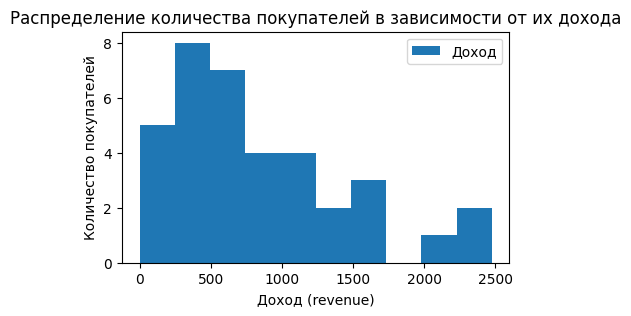

In [139]:
data = df['revenue']
hist, ax = plt.subplots(figsize=(5, 3))
ax.hist(data, bins=10,label='Доход')
ax.legend()
ax.set_title("Распределение количества покупателей в зависимости от их дохода")
ax.set_xlabel("Доход (revenue)")
ax.set_ylabel("Количество покупателей")
plt.show()

На гитограмме показано количество покупателей с разным доходом. Максимальное количество - 8 при доходе 250-500

### 2. Боксплот

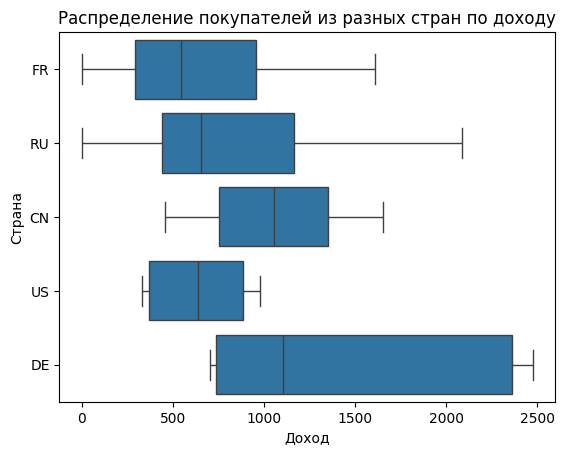

In [140]:
import seaborn as sns
bp = sns.boxplot(data=df, y="country", x="revenue", orient="h")
bp.set_title("Распределение покупателей из разных стран по доходу")
bp.set_ylabel("Страна")
bp.set_xlabel("Доход")

plt.show()

На боксплоте показано распределение дохода покупателей из разных стран по доходу. Выбросов нет

### 3. scatter plot

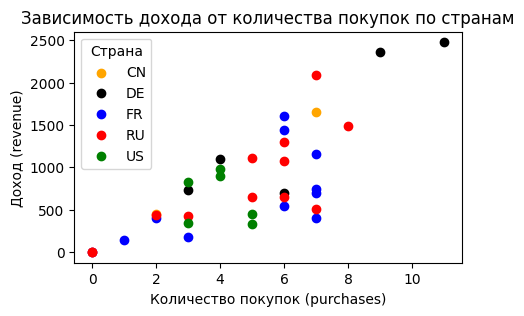

In [141]:
# Цвета для стран
country_colors = {
    'FR': 'blue',
    'RU': 'red',
    'DE': 'black',
    'CN': 'orange',
    'US': 'green'
}

scat, ax = plt.subplots(figsize=(5, 3))

for country, group in df.groupby('country'):
    ax.scatter(group['purchases'],group['revenue'],label=country,color=country_colors.get(country, 'gray'))

ax.set_title('Зависимость дохода от количества покупок по странам')
ax.set_xlabel('Количество покупок (purchases)')
ax.set_ylabel('Доход (revenue)')
ax.legend(title='Страна')

plt.show()

На графике показано распределение групп покупателей по странам с зависисмостью доходда от количества покупок. Можно сделать логичный вывод, что чем больше покупок совершил покупатель, тем больше его доход

### 4. Сохранение

In [142]:
hist.savefig('figures/histogram.png')
bp.figure.savefig('figures/boxplot.png')
scat.savefig('figures/scatter.png')